### **Web Scraping for reviews of Elden Ring on Steam**

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# Elden Ring Steam Reviews — Web Scraper
# Output: raw_reviews.json + raw_reviews.csv
# ============================================================

import requests
import time
import json
import csv
from datetime import datetime


# ============================================================
# Step 1: Fetch Reviews from Steam API
# ============================================================

def fetch_reviews(app_id="1245620", target=20000, language="english"):
    url     = f"https://store.steampowered.com/appreviews/{app_id}"
    reviews = []
    cursor  = "*"
    batch   = 1

    print(f"Fetching {target} reviews for App ID: {app_id}...\n")

    while len(reviews) < target:
        params = {
            "json"          : 1,
            "language"      : language,
            "filter"        : "all",
            "review_type"   : "all",
            "purchase_type" : "all",
            "num_per_page"  : 100,
            "cursor"        : cursor,
        }

        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
        except requests.exceptions.RequestException as e:
            print(f"Request error on batch {batch}: {e}")
            break
        except json.JSONDecodeError:
            print(f"JSON parse error on batch {batch}")
            break

        if not data.get("success"):
            print(f"API returned failure on batch {batch}")
            break

        batch_reviews = data.get("reviews", [])

        if not batch_reviews:
            print(f"No more reviews available. Stopped at {len(reviews)}.")
            break

        reviews.extend(batch_reviews)
        new_cursor = data.get("cursor", "")

        print(f"Batch {batch:>3} | This batch: {len(batch_reviews):>3} | "
              f"Total: {len(reviews):>5} / {target}")

        if new_cursor == cursor:
            print("Cursor unchanged — reached last page.")
            break

        cursor = new_cursor
        batch += 1
        time.sleep(1)  # Avoid rate limiting

    reviews = reviews[:target]
    print(f"\nDone! Total reviews fetched: {len(reviews)}")
    return reviews


# ============================================================
# Step 2: Save Raw JSON
# ============================================================

def save_raw_json(reviews, filename="raw_reviews.json"):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(reviews, f, ensure_ascii=False, indent=2)
    print(f"Saved raw JSON → {filename}")


# ============================================================
# Step 3: Save Raw CSV
# ============================================================

def save_raw_csv(reviews, filename="raw_reviews.csv"):
    if not reviews:
        print("No data to save.")
        return

    fields = [
        "review_id", "recommended", "playtime_hours",
        "review_text", "timestamp", "helpful_votes"
    ]

    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()

        for r in reviews:
            writer.writerow({
                "review_id"     : r.get("recommendationid", ""),
                "recommended"   : "Yes" if r.get("voted_up") else "No",
                "playtime_hours": round(
                    r["author"].get("playtime_forever", 0) / 60, 1
                ),
                "review_text"   : r.get("review", "").replace("\n", " ")[:300],
                "timestamp"     : datetime.utcfromtimestamp(
                    r.get("timestamp_created", 0)
                ).strftime("%Y-%m-%d %H:%M:%S"),
                "helpful_votes" : r.get("votes_up", 0),
            })

    print(f"Saved raw CSV  → {filename}")


# ============================================================
# Run
# ============================================================

if __name__ == "__main__":
    reviews = fetch_reviews(target=20000)
    save_raw_json(reviews)
    save_raw_csv(reviews)

Fetching 20000 reviews for App ID: 1245620...

Batch   1 | This batch: 100 | Total:   100 / 20000
Batch   2 | This batch: 100 | Total:   200 / 20000
Batch   3 | This batch: 100 | Total:   300 / 20000
Batch   4 | This batch: 100 | Total:   400 / 20000
Batch   5 | This batch: 100 | Total:   500 / 20000
Batch   6 | This batch: 100 | Total:   600 / 20000
Batch   7 | This batch: 100 | Total:   700 / 20000
Batch   8 | This batch: 100 | Total:   800 / 20000
Batch   9 | This batch: 100 | Total:   900 / 20000
Batch  10 | This batch: 100 | Total:  1000 / 20000
Batch  11 | This batch: 100 | Total:  1100 / 20000
Batch  12 | This batch: 100 | Total:  1200 / 20000
Batch  13 | This batch: 100 | Total:  1300 / 20000
Batch  14 | This batch: 100 | Total:  1400 / 20000
Batch  15 | This batch: 100 | Total:  1500 / 20000
Batch  16 | This batch: 100 | Total:  1600 / 20000
Batch  17 | This batch: 100 | Total:  1700 / 20000
Batch  18 | This batch: 100 | Total:  1800 / 20000
Batch  19 | This batch: 100 | Total

# **Sentiment Analysis**

In [3]:
# Sentiment Analysis
!pip install wordcloud scikit-learn nltk matplotlib

In [4]:
# ============================================================
# Elden Ring Steam Reviews — Sentiment Analysis
# Improvements:
# 1. Logistic Regression
# 2. Word cloud grouped by playtime (short/mid/long players)
# 3. Core charts: Sentiment score vs playtime + inflection points
# ============================================================

import re
import json
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


# ============================================================
# Step 1: Load Scraped Data
# ============================================================

def load_steam_reviews(filename="raw_reviews.json"):
    with open(filename, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records = []
    for r in raw:
        records.append({
            "review_id"      : r.get("recommendationid", ""),
            "text"           : r.get("review", ""),
            "sentiment"      : "Positive" if r.get("voted_up") else "Negative",
            "playtime_hours" : round(r["author"].get("playtime_forever", 0) / 60, 1),
            "helpful_votes"  : r.get("votes_up", 0),
        })

    df = pd.DataFrame(records)
    df = df[df["text"].str.strip() != ""].reset_index(drop=True)
    print(f"✅ Loaded {len(df)} valid reviews")
    return df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
# ============================================================
# Step 2: Text Preprocessing
# ============================================================

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def remove_urls(text):
    return re.sub(r'((http://)[^\s]*|(https://)[^\s]*|(www\.)[^\s]*)', ' ', text)

def remove_punctuations(text):
    return re.sub(r"[~.,%/:;?_&+*=!@#$^()-]", " ", text)

def remove_numbers(text):
    return re.sub(r'[0-9]+', '', text)

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w.lower() not in stop_words])

def apply_stemming(text):
    tokens = nltk.word_tokenize(text)
    return " ".join([stemmer.stem(w) for w in tokens])

def apply_lemmatization(text):
    tokens = nltk.word_tokenize(text)
    return " ".join([lemmatizer.lemmatize(w) for w in tokens])

def preprocess(text):
    text = text.lower()
    text = remove_urls(text)
    text = remove_punctuations(text)
    text = remove_numbers(text)
    text = remove_stopwords(text)
    text = apply_stemming(text)
    text = apply_lemmatization(text)
    return text.strip()

def preprocess_dataframe(df):
    print("⏳ Preprocessing text...")
    df["clean_text"] = df["text"].apply(preprocess)
    df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
    print(f"✅ Preprocessing complete: {len(df)} reviews")
    return df

In [6]:
# ============================================================
# Step 3: Word Cloud (Grouped by Playtime)
# ============================================================

def plot_wordclouds_by_playtime(df):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    groups = {
        "Short Players (0-50h)"  : df[df["playtime_hours"] < 50],
        "Mid Players (50-300h)"  : df[
            (df["playtime_hours"] >= 50) & (df["playtime_hours"] < 300)
        ],
        "Long Players (300h+)"   : df[df["playtime_hours"] >= 300],
    }

    for ax, (title, group) in zip(axes, groups.items()):
        text = " ".join(group["clean_text"])
        if not text.strip():
            ax.set_title(f"{title}\n(No data)", fontsize=13)
            ax.axis("off")
            continue
        wc = WordCloud(background_color="white", max_words=100,
                       width=800, height=600).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.axis("off")

    plt.suptitle("What Do Players Talk About at Different Playtime Stages?",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig("wordcloud_by_playtime.png", dpi=150)
    plt.show()
    print("✅ Word cloud saved → wordcloud_by_playtime.png")

In [7]:
# ============================================================
# Step 4: Train Logistic Regression Model
# ============================================================

def train_model(df):
    X = df["clean_text"]
    y = df["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=123
    )

    vectorizer  = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    print("\n📊 Training Logistic Regression model...")
    lr = LogisticRegression(max_iter=10000, random_state=123)
    lr.fit(X_train_vec, y_train)
    lr_pred = lr.predict(X_test_vec)

    print(f"  Training Accuracy : {lr.score(X_train_vec, y_train):.4f}")
    print(f"  Test Accuracy     : {lr.score(X_test_vec, y_test):.4f}")

    # Confusion Matrix
    cm   = confusion_matrix(y_test, lr_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix — Logistic Regression")
    plt.savefig("confusion_matrix_Logistic_Regression.png", dpi=150)
    plt.show()
    print("✅ Confusion matrix saved → confusion_matrix_Logistic_Regression.png")

    return vectorizer, lr

In [9]:
# ============================================================
# Step 5: Compute Sentiment Score (0.0 to 1.0)
# ============================================================

def add_sentiment_score(df, vectorizer, lr_model):
    vec   = vectorizer.transform(df["clean_text"])
    proba = lr_model.predict_proba(vec)

    classes = list(lr_model.classes_)
    pos_idx = classes.index("Positive")
    df["sentiment_score"] = proba[:, pos_idx]

    print("✅ Sentiment scores computed (0 = most negative, 1 = most positive)")
    return df

In [8]:
# ============================================================
# Step 6: Sentiment Score vs Playtime Correlation Analysis
# ============================================================

def analyze_score_vs_playtime(df):
    df_filtered = df[
        (df["playtime_hours"] > 0) & (df["playtime_hours"] < 2000)
    ].copy()

    # Group playtime into buckets
    bins   = [0, 10, 50, 100, 300, 500, 2000]
    labels = ["0-10h", "10-50h", "50-100h", "100-300h", "300-500h", "500h+"]
    df_filtered["playtime_group"] = pd.cut(
        df_filtered["playtime_hours"], bins=bins, labels=labels
    )

    # --- Plot 1: Scatter plot + Trend line ---
    plt.figure(figsize=(12, 6))
    plt.scatter(df_filtered["playtime_hours"], df_filtered["sentiment_score"],
                alpha=0.3, s=10, color="steelblue")
    z      = np.polyfit(df_filtered["playtime_hours"], df_filtered["sentiment_score"], 1)
    p      = np.poly1d(z)
    x_line = np.linspace(0, df_filtered["playtime_hours"].max(), 200)
    plt.plot(x_line, p(x_line), "r--", linewidth=2, label="Trend Line")
    plt.xlabel("Playtime (hours)")
    plt.ylabel("Sentiment Score (0 = most negative, 1 = most positive)")
    plt.title("Sentiment Score vs Playtime")
    plt.legend()
    plt.tight_layout()
    plt.savefig("score_vs_playtime_scatter.png", dpi=150)
    plt.show()
    print("✅ Scatter plot saved → score_vs_playtime_scatter.png")

    # --- Plot 2: Average sentiment score by playtime group ---
    group_stats = df_filtered.groupby(
        "playtime_group", observed=True
    )["sentiment_score"].agg(["mean", "std", "count"]).reset_index()

    plt.figure(figsize=(12, 6))
    bars = plt.bar(group_stats["playtime_group"].astype(str),
                   group_stats["mean"],
                   yerr=group_stats["std"],
                   capsize=5, color="steelblue", alpha=0.8)
    plt.xlabel("Playtime Group")
    plt.ylabel("Average Sentiment Score")
    plt.title("Average Sentiment Score by Playtime Group")
    plt.ylim(0, 1)
    for bar, count in zip(bars, group_stats["count"]):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"n={count}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("score_by_playtime_group.png", dpi=150)
    plt.show()
    print("✅ Group bar chart saved → score_by_playtime_group.png")

    # --- Plot 3: Sentiment inflection point detection ---
    df_sorted = df_filtered.sort_values("playtime_hours")
    window    = max(10, len(df_sorted) // 50)
    df_sorted["rolling_score"] = df_sorted["sentiment_score"].rolling(
        window=window, min_periods=1, center=True
    ).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(df_sorted["playtime_hours"], df_sorted["rolling_score"],
             color="steelblue", linewidth=2)
    plt.axhline(y=0.5, color="gray", linestyle="--",
                alpha=0.7, label="Neutral Line (0.5)")

    rolling = df_sorted["rolling_score"].values
    for i in range(1, len(rolling) - 1):
        if rolling[i] < rolling[i-1] and rolling[i] < rolling[i+1]:
            if rolling[i] < 0.45:
                plt.annotate("⚠️ Inflection Point",
                             xy=(df_sorted["playtime_hours"].iloc[i], rolling[i]),
                             xytext=(df_sorted["playtime_hours"].iloc[i] + 10,
                                     rolling[i] + 0.05),
                             arrowprops=dict(arrowstyle="->", color="red"),
                             color="red", fontsize=9)
                break

    plt.xlabel("Playtime (hours)")
    plt.ylabel("Average Sentiment Score (Rolling Mean)")
    plt.title(f"Sentiment Inflection Point Detection (Window = {window})")
    plt.legend()
    plt.tight_layout()
    plt.savefig("sentiment_inflection_points.png", dpi=150)
    plt.show()
    print("✅ Inflection point chart saved → sentiment_inflection_points.png")

    # Pearson correlation
    corr = df_filtered["playtime_hours"].corr(df_filtered["sentiment_score"])
    print(f"\n📈 Pearson Correlation (Playtime vs Sentiment Score): {corr:.4f}")
    print(f"   {'Positive correlation (more playtime → more positive)' if corr > 0 else 'Negative correlation (more playtime → more negative)'}")

    return df_filtered

✅ Loaded 19965 valid reviews
⏳ Preprocessing text...
✅ Preprocessing complete: 19640 reviews


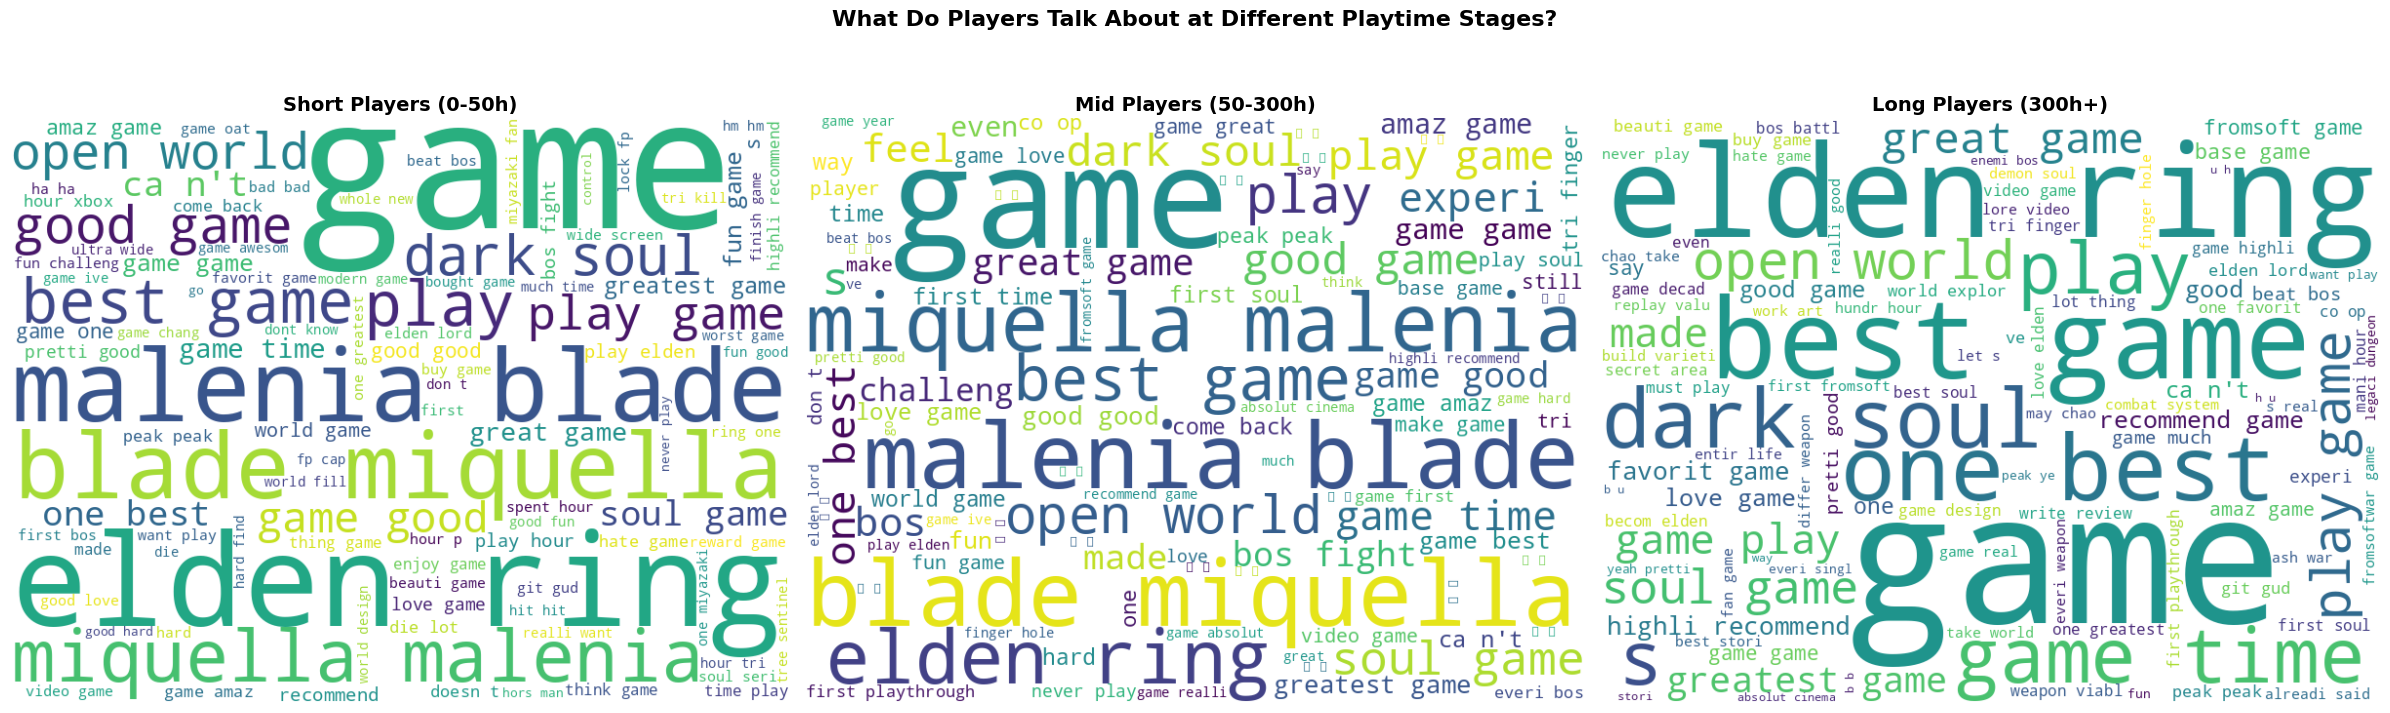

✅ Word cloud saved → wordcloud_by_playtime.png

📊 Training Logistic Regression model...
  Training Accuracy : 0.9646
  Test Accuracy     : 0.9520


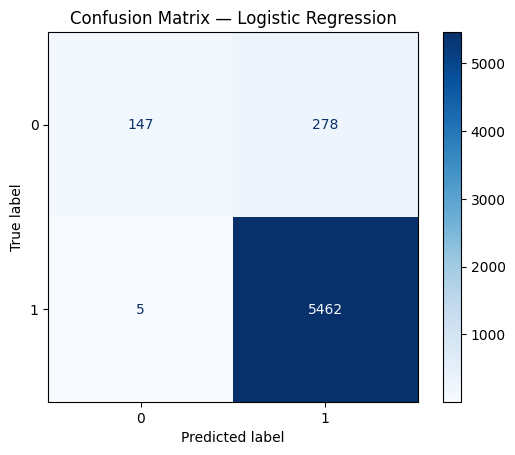

✅ Confusion matrix saved → confusion_matrix_Logistic_Regression.png
✅ Sentiment scores computed (0 = most negative, 1 = most positive)


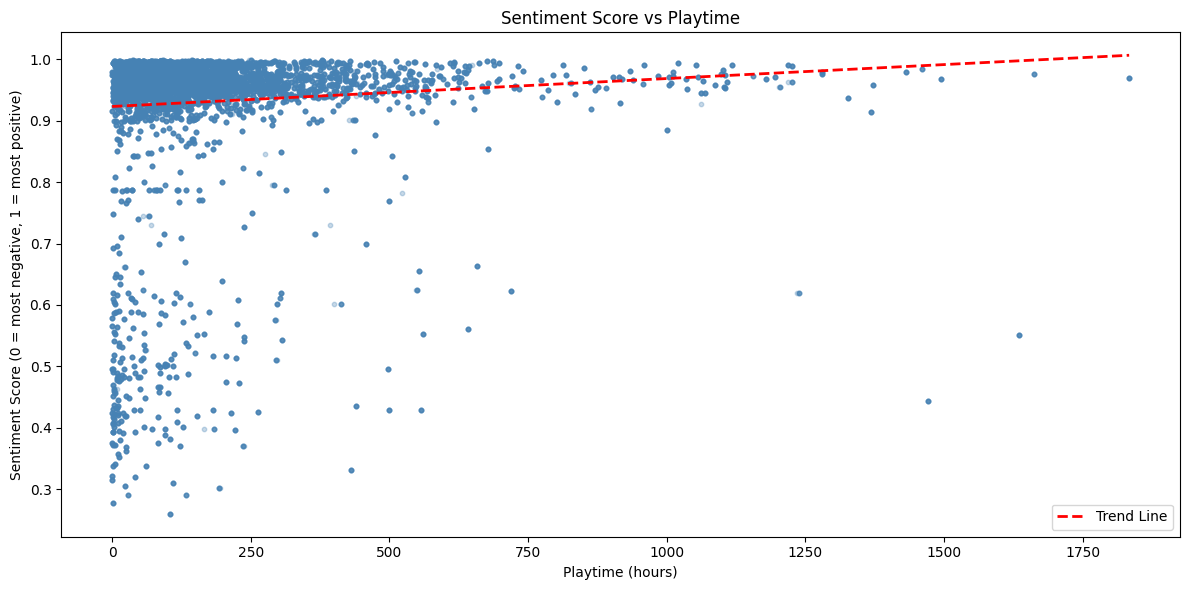

✅ Scatter plot saved → score_vs_playtime_scatter.png


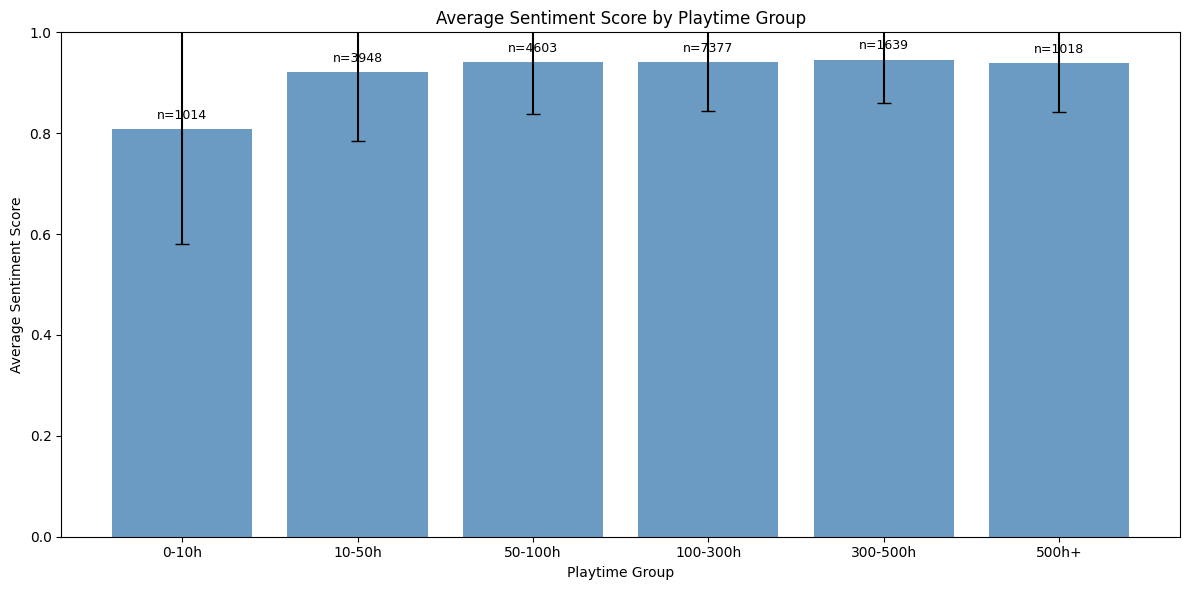

✅ Group bar chart saved → score_by_playtime_group.png


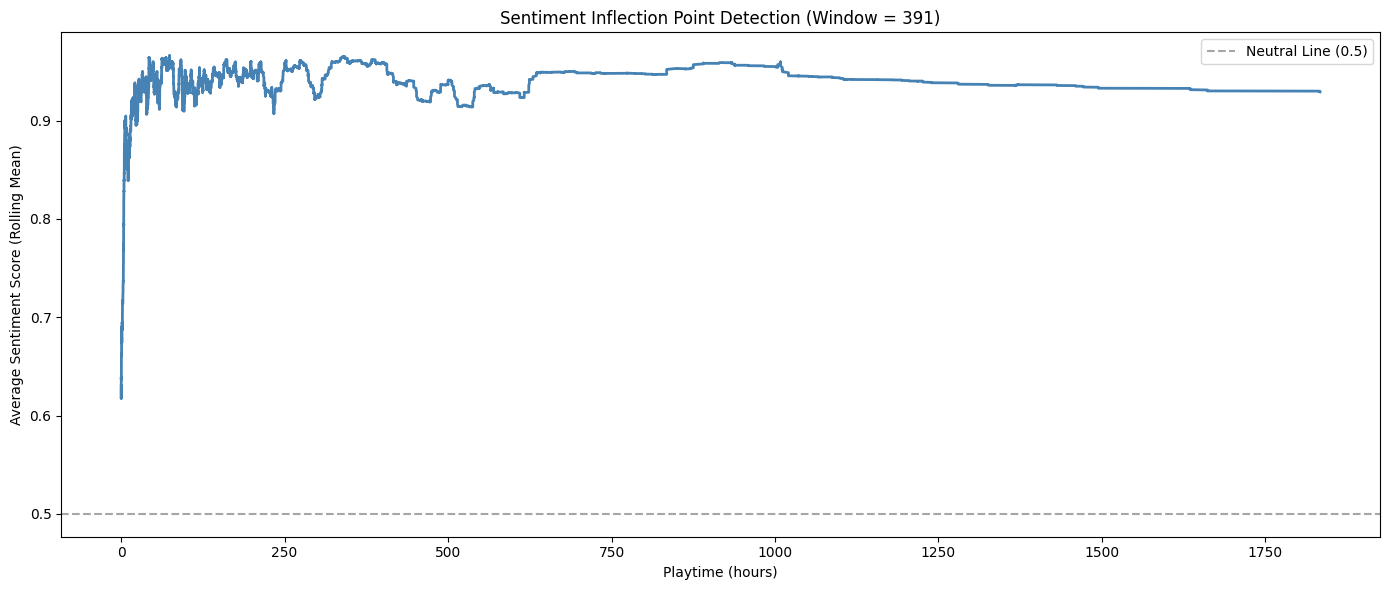

✅ Inflection point chart saved → sentiment_inflection_points.png

📈 Pearson Correlation (Playtime vs Sentiment Score): 0.0714
   Positive correlation (more playtime → more positive)

✅ Results saved → sentiment_results.csv


In [10]:
# ============================================================
# Step 7: Save Results
# ============================================================

def save_results(df, filename="sentiment_results.csv"):
    df.to_csv(filename, index=False, encoding="utf-8")
    print(f"\n✅ Results saved → {filename}")


# ============================================================
# Run
# ============================================================



df = load_steam_reviews("raw_reviews.json")
df = preprocess_dataframe(df)
plot_wordclouds_by_playtime(df)
vectorizer, lr_model = train_model(df)
df = add_sentiment_score(df, vectorizer, lr_model)
df = analyze_score_vs_playtime(df)
save_results(df)

# **Topic Modeling**

In [11]:
# ============================================================
# Cell 1: Install Dependencies
# ============================================================
!pip install -q pandas gensim pyLDAvis bertopic nltk matplotlib seaborn scikit-learn umap-learn

In [14]:
# ============================================================
# Cell 2: Imports
# ============================================================
!pip install -q langdetect

import warnings
import logging
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.ERROR)  # Suppress gensim/BERTopic log messages

import json
import re
import nltk
import gensim
import gensim.corpora as corpora
import pyLDAvis
import pyLDAvis.gensim_models
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from umap import UMAP
from bertopic import BERTopic
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer
from langdetect import detect, LangDetectException, DetectorFactory
DetectorFactory.seed = 42  # Fix langdetect random seed for reproducibility

# quiet=True suppresses NLTK download progress messages
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

print('✅ All imports successful')

✅ All imports successful


In [15]:
# ============================================================
# Cell 3: Load Data (langdetect English filter)
# replaced ASCII heuristic with langdetect for accurate
#          language detection — removes Swedish and other non-English
# ============================================================
!pip install -q langdetect

from langdetect import detect, LangDetectException

def is_english(text):
    if not text or len(text.strip()) == 0:
        return False
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False


def load_reviews(filename='raw_reviews.json', limit=2000):
    with open(filename, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    records = []
    for r in raw:
        text = r.get('review', '')
        if text.strip() and is_english(text):
            records.append({
                'review_id'      : r.get('recommendationid', ''),
                'text'           : text,
                'sentiment'      : 'Positive' if r.get('voted_up') else 'Negative',
                'playtime_hours' : round(r['author'].get('playtime_forever', 0) / 60, 1),
            })
        if len(records) >= limit:
            break

    df = pd.DataFrame(records)
    print(f'✅ Loaded {len(df)} English reviews (limit={limit})')
    print(f'   Positive: {(df["sentiment"] == "Positive").sum()} | '
          f'Negative: {(df["sentiment"] == "Negative").sum()}')
    return df

In [16]:
# ============================================================
# Cell 4: Tokenisation + Lemmatisation
# ============================================================
nltk_stopwords = set(stopwords.words('english'))
custom_stopwords = {
    # Gaming-specific stopwords
    'game', 'play', 'played', 'playing', 'player', 'games',
    'elden', 'ring', 'fromsoftware', 'souls', 'bosses', 'bos',
    'gaming',

    # Generic verbs
    'go', 'going', 'say', 'said', 'find', 'makes', 'take',
    'come', 'see', 'look', 'try', 'use', 'put', 'give',
    'make', 'made', 'open', 'hold', 'using', 'trying', 'mean',
    'end', 'start', 'finish',

    # Generic modal verbs
    'would', 'could', 'might', 'shall', 'must',

    # Generic adverbs and intensifiers
    'really', 'even', 'much', 'actually', 'just', 'still',
    'always', 'sometimes', 'never', 'ever', 'absolutely',
    'truly', 'highly', 'extremely', 'especially', 'pretty',
    'super', 'enough', 'honestly', 'far', 'almost',
    'kinda', 'finally', 'quite', 'overall', 'probably',
    'definitely',

    # Generic adjectives
    'good', 'great', 'bad', 'best', 'better', 'big', 'new',
    'hard', 'dark', 'long', 'different', 'whole', 'every',
    'entire', 'cool', 'easier', 'absolute',

    # Generic nouns
    'thing', 'things', 'stuff', 'people', 'person',
    'world', 'life', 'time', 'times', 'year', 'years',
    'hours', 'lot', 'bit', 'way', 'back', 'hole',
    'point', 'man', 'god', 'rock', 'ball',
    'sense',

    # Generic conjunctions and prepositions
    'though', 'yet', 'else', 'around', 'without',
    'however',

    # Generic pronouns
    'something', 'nothing', 'anything', 'everything',
    'someone', 'anyone', 'everyone', 'another',
    'thee',

    # Generic affirmations and filler words
    'yes', 'yeah', 'okay', 'like', 'one', 'first', 'also',
    'fun', 'love', 'well', 'feel', 'think', 'know',
    'want', 'need', 'get', 'got', 'many', 'little',
    'second',

    # Generic emotional words
    'felt', 'feels',

    # Internet slang and informal language
    'im', 'ive', 'dont', 'cant', 'didnt', 'youre', 'its',
    'u', 'ur', 'lol', 'ye', 'gud', 'idk',

    # Meta-review language
    'recommend', 'recomend', 'please', 'review',

    # Player self-description
    'jag',

    # Technical noise
    'http', 'gt', 'ca',

    # English number words
    'two',
}
final_stopwords = nltk_stopwords.union(custom_stopwords)

# Abbreviation normalisation table
ABBREVIATIONS = {
    'att'  : 'attack',
    'bos'  : 'boss',
    'dmg'  : 'damage',
    'def'  : 'defense',
    'str'  : 'strength',
    'dex'  : 'dexterity',
    'int'  : 'intelligence',
    'hp'   : 'health',
    'fp'   : 'focus',
    'npc'  : 'character',
    'op'   : 'overpowered',
    'pve'  : 'singleplayer',
    'pvp'  : 'multiplayer',
    'gg'   : 'good',
    'rng'  : 'random',
    'gud'  : 'good',
    'oat'  : 'of all time'
}

lemmatizer = WordNetLemmatizer()


def tokenize_text(text):
    words = word_tokenize(str(text))

    # Step 1: w.isalpha() — excludes numbers and symbols
    tokens = [
        w.lower()
        for w in words
        if w.isalpha() and w.lower() not in final_stopwords
    ]

    # Step 2: normalise abbreviations to full words
    tokens = [ABBREVIATIONS.get(t, t) for t in tokens]

    # Step 3: lemmatisation — unify inflected forms
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 4: re-filter after lemmatisation
    tokens = [t for t in tokens if t not in final_stopwords and len(t) > 1]

    return tokens


def tokenize_dataframe(df):
    print('⏳ Tokenizing and lemmatising reviews...')
    df = df.copy()
    df['tokens'] = df['text'].apply(tokenize_text)
    df = df[df['tokens'].map(len) > 0].reset_index(drop=True)
    print(f'✅ Tokenization complete: {len(df)} reviews kept')
    return df

In [17]:
# ============================================================
# Cell 5: Find Optimal Number of Topics
# — Run this FIRST before training the final LDA
# ============================================================
def find_optimal_topics(df, topic_range=range(2, 20)):
    tokenized  = df['tokens'].tolist()
    dictionary = corpora.Dictionary(tokenized)
    corpus     = [dictionary.doc2bow(t) for t in tokenized]

    coherence_scores = []
    print('⏳ Finding optimal number of topics...')

    for n in topic_range:
        model = gensim.models.LdaModel(
            corpus=corpus, id2word=dictionary,
            num_topics=n, random_state=42,
            passes=10, iterations=200,
        )
        score = CoherenceModel(
            model=model, texts=tokenized,
            dictionary=dictionary, coherence='c_v',
        ).get_coherence()
        coherence_scores.append(score)
        print(f'  Num Topics: {n:>2} | Coherence Score: {score:.4f}')

    optimal_n = list(topic_range)[coherence_scores.index(max(coherence_scores))]

    plt.figure(figsize=(9, 5))
    plt.plot(list(topic_range), coherence_scores,
             marker='o', linestyle='-', color='steelblue')
    plt.axvline(x=optimal_n, color='red', linestyle='--',
                label=f'Optimal: {optimal_n} topics')
    plt.xlabel('Number of Topics')
    plt.ylabel('Coherence Score (c_v)')
    plt.title('Coherence Score vs. Number of Topics\n(Elden Ring Steam Reviews)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('1_coherence_vs_topics.png', dpi=150)
    plt.show()

    print(f'\n✅ Optimal Number of Topics: {optimal_n}')
    print('✅ Saved → 1_coherence_vs_topics.png')
    return optimal_n, coherence_scores

In [18]:
# ============================================================
# Cell 6: Train Final LDA Model (with optimal topic count)
# ============================================================
def train_lda(df, num_topics=5):
    dictionary = corpora.Dictionary(df['tokens'])
    corpus     = [dictionary.doc2bow(text) for text in df['tokens']]

    print(f'\n⏳ Training LDA model with {num_topics} topics...')
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=15,
        iterations=500,
        alpha='auto',
        eta='auto',
        minimum_probability=0.01,
    )

    print('\n=== LDA Topics ===')
    for topic_id, words in lda_model.show_topics(
        num_topics=num_topics, num_words=10, formatted=False
    ):
        print(f'Topic {topic_id + 1}: {[word for word, _ in words]}')

    return lda_model, corpus, dictionary

In [19]:
# ============================================================
# Cell 7: Train BERTopic (for comparison)
# ============================================================
def train_bertopic(df):
    print('\n⏳ Training BERTopic model (for comparison only)...')
    umap_model       = UMAP(n_neighbors=15, n_components=5,
                            min_dist=0.0, metric='cosine', random_state=42)
    vectorizer_model = CountVectorizer(stop_words=list(final_stopwords))
    topic_model      = BERTopic(umap_model=umap_model,
                                vectorizer_model=vectorizer_model)
    topics, probs    = topic_model.fit_transform(df['text'].tolist())

    bertopic_topics   = topic_model.get_topics()
    valid_topic_count = sum(1 for k in bertopic_topics if k != -1)
    print(f'\n=== BERTopic: {valid_topic_count} Topics Found ===')
    for topic_id, words in bertopic_topics.items():
        if topic_id != -1:
            print(f'Topic {topic_id + 1}: {[word for word, _ in words[:10]]}')

    return topic_model, topics, probs

In [20]:
# ============================================================
# Cell 8: Coherence Score Comparison
# — Uses FINAL optimal LDA vs BERTopic (fair comparison)
# ============================================================
def compare_coherence(lda_model, topic_model, df, dictionary):
    print('\n⏳ Computing coherence scores...')

    # LDA coherence
    coherence_lda = CoherenceModel(
        model=lda_model, texts=df['tokens'],
        dictionary=dictionary, coherence='c_v',
    ).get_coherence()

    # BERTopic coherence
    all_topics       = topic_model.get_topics()
    ber_topic_tokens = [
        [str(word) for word, _ in words[:10] if str(word).strip()]
        for topic_id, words in all_topics.items()
        if topic_id != -1
    ]
    coherence_bert = 0.0
    if ber_topic_tokens:
        try:
            coherence_bert = CoherenceModel(
                topics=ber_topic_tokens, texts=df['tokens'],
                dictionary=dictionary, coherence='c_v',
            ).get_coherence()
        except Exception as e:
            print(f'⚠️ BERTopic coherence failed: {e}')

    print(f'\n📊 LDA Coherence Score     : {coherence_lda:.3f}')
    print(f'📊 BERTopic Coherence Score: {coherence_bert:.3f}')
    winner = 'LDA' if coherence_lda >= coherence_bert else 'BERTopic'
    print(f'→ Higher Coherence        : {winner}')

    plt.figure(figsize=(7, 5))
    plt.bar(['LDA', 'BERTopic'], [coherence_lda, coherence_bert],
            color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
    plt.ylabel('Coherence Score (c_v)')
    plt.title('Coherence Score: LDA vs BERTopic\n(Elden Ring Steam Reviews)')
    plt.ylim(0, 1)
    for i, val in enumerate([coherence_lda, coherence_bert]):
        plt.text(i, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('2_coherence_comparison.png', dpi=150)
    plt.show()
    print('✅ Saved → 2_coherence_comparison.png')
    return coherence_lda, coherence_bert

In [21]:
# ============================================================
# Cell 9: Topic Diversity Score Comparison
# ============================================================
def calculate_lda_diversity(lda_model, top_n=10):
    topics = lda_model.show_topics(
        num_topics=lda_model.num_topics, num_words=top_n, formatted=False)
    unique_words = set()
    for _, word_list in topics:
        unique_words.update([w for w, _ in word_list])
    return len(unique_words) / (top_n * lda_model.num_topics)


def calculate_bert_diversity(topic_model, top_n=10):
    all_topics   = topic_model.get_topics()
    valid_topics = {k: v for k, v in all_topics.items() if k != -1}
    unique_words = set()
    for topic_words in valid_topics.values():
        unique_words.update([w for w, _ in topic_words[:top_n]])
    if not valid_topics:
        return 0.0
    return len(unique_words) / (top_n * len(valid_topics))


def compare_diversity(lda_model, topic_model):
    lda_div  = calculate_lda_diversity(lda_model)
    bert_div = calculate_bert_diversity(topic_model)

    print(f'\n📊 LDA Topic Diversity Score     : {lda_div:.3f}')
    print(f'📊 BERTopic Topic Diversity Score: {bert_div:.3f}')

    plt.figure(figsize=(7, 5))
    plt.bar(['LDA', 'BERTopic'], [lda_div, bert_div],
            color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
    plt.ylabel('Topic Diversity Score')
    plt.title('Topic Diversity: LDA vs BERTopic\n(Elden Ring Steam Reviews)')
    plt.ylim(0, 1)
    for i, val in enumerate([lda_div, bert_div]):
        plt.text(i, val + 0.02, f'{val:.3f}', ha='center',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('3_diversity_comparison.png', dpi=150)
    plt.show()
    print('✅ Saved → 3_diversity_comparison.png')
    return lda_div, bert_div

In [22]:
# ============================================================
# Cell 10: LDA Top Keywords per Topic
# ============================================================
def plot_lda_keywords(lda_model, num_words=10):
    num_topics = lda_model.num_topics
    cols       = min(3, num_topics)
    rows       = (num_topics + cols - 1) // cols
    colors     = list(mcolors.TABLEAU_COLORS.values())

    fig, axes = plt.subplots(rows, cols,
                             figsize=(8 * cols, 5 * rows),
                             squeeze=False)

    for idx in range(num_topics):
        ax        = axes[idx // cols][idx % cols]
        top_words = lda_model.show_topic(idx, topn=num_words)
        words     = [w for w, _ in top_words]
        scores    = [s for _, s in top_words]
        ax.barh(words[::-1], scores[::-1], color=colors[idx % len(colors)])
        ax.set_title(f'Topic {idx + 1}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Word Probability')

    for idx in range(num_topics, rows * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    plt.suptitle('LDA Top Keywords per Topic\n(Elden Ring Steam Reviews)',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('4_lda_keywords.png', dpi=150)
    plt.show()
    print('✅ Saved → 4_lda_keywords.png')

In [23]:
# ============================================================
# Cell 11: LDA Topic Distribution
# ============================================================
def plot_lda_topic_distribution(lda_model, corpus, df):
    dominant_topics = []
    for doc_bow in corpus:
        topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        dominant   = max(topic_dist, key=lambda x: x[1])
        dominant_topics.append(dominant[0] + 1)  # 1-based

    df = df.copy()
    df['dominant_topic'] = dominant_topics

    topic_counts = df['dominant_topic'].value_counts().sort_index()
    total        = topic_counts.sum()

    print('\n=== LDA Topic Distribution ===')
    for t, cnt in topic_counts.items():
        print(f'  Topic {t}: {cnt} reviews ({cnt/total*100:.1f}%)')

    plt.figure(figsize=(10, 5))
    bars = plt.bar([f'Topic {t}' for t in topic_counts.index],
                   topic_counts.values, color='steelblue', alpha=0.85)
    plt.xlabel('Topic')
    plt.ylabel('Number of Reviews')
    plt.title('LDA Topic Distribution\n(Elden Ring Steam Reviews)')
    for bar, cnt in zip(bars, topic_counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'{cnt}\n({cnt/total*100:.1f}%)',
                 ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('5_lda_topic_distribution.png', dpi=150)
    plt.show()
    print('✅ Saved → 5_lda_topic_distribution.png')
    return df

In [24]:
# ============================================================
# Cell 12: Sentiment Breakdown per LDA Topic
# — KEY chart for analysing Elden Ring's success
# ============================================================
def plot_sentiment_by_topic(df):
    cross = pd.crosstab(
        df['dominant_topic'], df['sentiment'], normalize='index'
    ) * 100

    for col in ['Positive', 'Negative']:
        if col not in cross.columns:
            cross[col] = 0

    cross = cross.sort_index()
    cross.index = [f'Topic {t}' for t in cross.index]

    ax = cross[['Positive', 'Negative']].plot(
        kind='bar', figsize=(12, 6),
        color=['#2ecc71', '#e74c3c'], alpha=0.85
    )
    plt.xlabel('Topic')
    plt.ylabel('Percentage (%)')
    plt.title('Positive vs Negative Review Ratio by LDA Topic\n(Elden Ring Steam Reviews)')
    plt.xticks(rotation=0)
    plt.legend(['Positive', 'Negative'])
    plt.ylim(0, 115)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)
    plt.tight_layout()
    plt.savefig('6_sentiment_by_topic.png', dpi=150)
    plt.show()
    print('✅ Saved → 6_sentiment_by_topic.png')
    print('\n=== Sentiment Ratio per Topic ===')
    print(cross.round(1).to_string())

In [25]:
# ============================================================
# Cell 13: Median Playtime by LDA Topic
# — Which topics do long-time players discuss?
# ============================================================
def plot_playtime_by_topic(df):
    # Load playtime from sentiment results or merge from original df
    df_filtered = df[
        (df['playtime_hours'] > 0) & (df['playtime_hours'] < 2000)
    ].copy()

    topic_playtime = df_filtered.groupby('dominant_topic')['playtime_hours'].agg(
        ['median', 'mean', 'count']
    ).reset_index()

    plt.figure(figsize=(12, 6))
    bars = plt.barh(
        [f'Topic {t}' for t in topic_playtime['dominant_topic']],
        topic_playtime['median'],
        color='steelblue', alpha=0.85
    )
    plt.xlabel('Median Playtime (hours)')
    plt.title('Median Playtime by LDA Topic\n(Which topics do long-time players discuss?)')

    for bar, val, cnt in zip(bars, topic_playtime['median'], topic_playtime['count']):
        plt.text(bar.get_width() + 1,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.0f}h (n={cnt})',
                 va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('7_playtime_by_topic.png', dpi=150)
    plt.show()
    print('✅ Saved → 7_playtime_by_topic.png')
    print('\n=== Median Playtime per Topic ===')
    print(topic_playtime.to_string(index=False))

In [26]:
# ============================================================
# Cell 14: pyLDAvis Interactive Visualisation
# ============================================================
def plot_pyldavis(lda_model, corpus, dictionary):
    print('\n⏳ Generating pyLDAvis visualisation...')

    # Suppress pyLDAvis logging output
    import logging
    logging.getLogger('pyLDAvis').setLevel(logging.ERROR)

    pyLDAvis.enable_notebook(local=True)
    vis = pyLDAvis.gensim_models.prepare(
        lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, 'lda_interactive.html')
    print('✅ Saved → lda_interactive.html')
    return vis

✅ Loaded 2000 English reviews (limit=2000)
   Positive: 1813 | Negative: 187
⏳ Tokenizing and lemmatising reviews...
✅ Tokenization complete: 1816 reviews kept
⏳ Finding optimal number of topics...
  Num Topics:  2 | Coherence Score: 0.3588
  Num Topics:  3 | Coherence Score: 0.3632
  Num Topics:  4 | Coherence Score: 0.3795
  Num Topics:  5 | Coherence Score: 0.3520
  Num Topics:  6 | Coherence Score: 0.3527
  Num Topics:  7 | Coherence Score: 0.3948
  Num Topics:  8 | Coherence Score: 0.3775
  Num Topics:  9 | Coherence Score: 0.3781
  Num Topics: 10 | Coherence Score: 0.3997
  Num Topics: 11 | Coherence Score: 0.3777
  Num Topics: 12 | Coherence Score: 0.3805
  Num Topics: 13 | Coherence Score: 0.3798
  Num Topics: 14 | Coherence Score: 0.3922
  Num Topics: 15 | Coherence Score: 0.3992
  Num Topics: 16 | Coherence Score: 0.3836
  Num Topics: 17 | Coherence Score: 0.3912
  Num Topics: 18 | Coherence Score: 0.3946
  Num Topics: 19 | Coherence Score: 0.4054


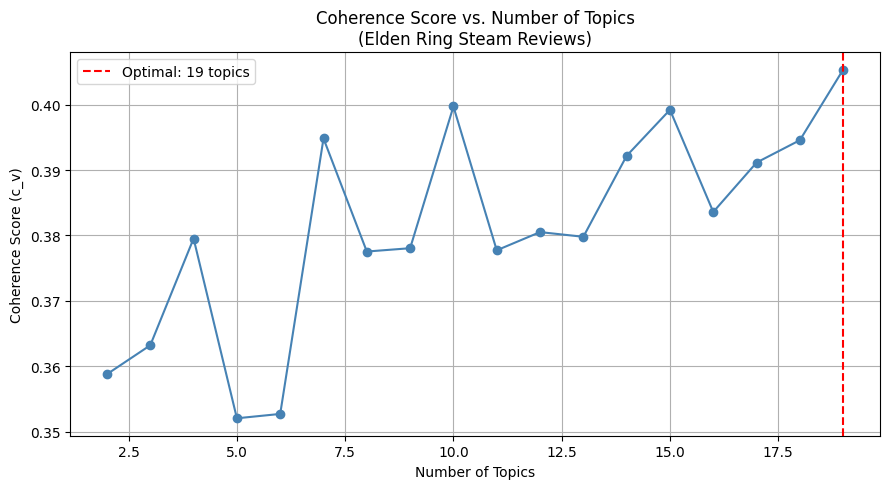


✅ Optimal Number of Topics: 19
✅ Saved → 1_coherence_vs_topics.png

⏳ Training comparison LDA with optimal 19 topics...

⏳ Training LDA model with 19 topics...

=== LDA Topics ===
Topic 1: ['epic', 'experience', 'amazing', 'woman', 'worth', 'dlc', 'control', 'friend', 'ruin', 'character']
Topic 2: ['suck', 'run', 'character', 'broken', 'dude', 'wan', 'took', 'na', 'kill', 'amazing']
Topic 3: ['weapon', 'beat', 'series', 'area', 'build', 'git', 'character', 'issue', 'monitor', 'real']
Topic 4: ['experience', 'amazing', 'nice', 'dlc', 'mod', 'run', 'frustrating', 'pc', 'feature', 'buy']
Topic 5: ['pc', 'build', 'tarnished', 'playthrough', 'masterpiece', 'xbox', 'explore', 'took', 'land', 'final']
Topic 6: ['enemy', 'story', 'experience', 'combat', 'character', 'fight', 'exploration', 'hand', 'build', 'item']
Topic 7: ['maidenless', 'easy', 'wish', 'goat', 'die', 'mind', 'item', 'hm', 'honest', 'annoying']
Topic 8: ['hate', 'top', 'challenging', 'goated', 'soulslike', 'amazing', 'explore

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


=== BERTopic: 34 Topics Found ===
Topic 1: ['boss', 'experience', 'design', 'doesnt', 'story', 'build', 'players', 'combat', 'difficult', 'exploration']
Topic 2: ['soulslike', 'epic', 'experience', 'combat', 'controls', 'enemies', 'rest', 'map', 'fan', 'soul']
Topic 3: ['boss', 'runes', 'beat', 'dodge', 'level', 'attacks', 'enemies', 'weapon', 'hit', 'hits']
Topic 4: ['hate', 'sucks', 'beat', 'worse', 'changed', 'ass', 'recommended', 'fact', 'calamity', 'crippling']
Topic 5: ['locked', 'support', 'fps', '60fps', '60', 'fix', 'unplayable', 'ultrawide', 'crashes', 'wide']
Topic 6: ['combat', 'beautiful', 'amazing', 'gameplay', 'lore', 'graphics', 'enemies', 'replayed', 'grind', 'story']
Topic 7: ['easy', 'lots', 'difficult', 'challenging', 'waste', 'nice', 'worked', 'rewarding', 'confusing', 'adventure']
Topic 8: ['1010', '1110', 'feet', 'worst', 'pissed', 'dollar', 'away', 'ten', 'broke', 'wall']
Topic 9: ['alright', 'guess', 'cream', 'nice', 'slop', 'sweet', 'perfection', 'ok', 'bodas

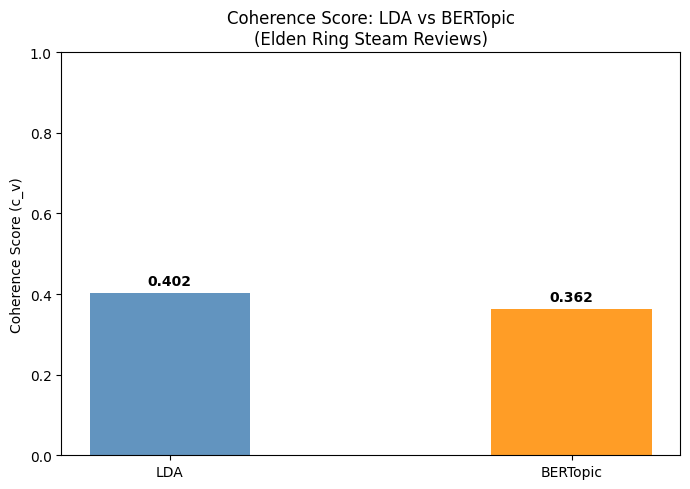

✅ Saved → 2_coherence_comparison.png

📊 LDA Topic Diversity Score     : 0.616
📊 BERTopic Topic Diversity Score: 0.921


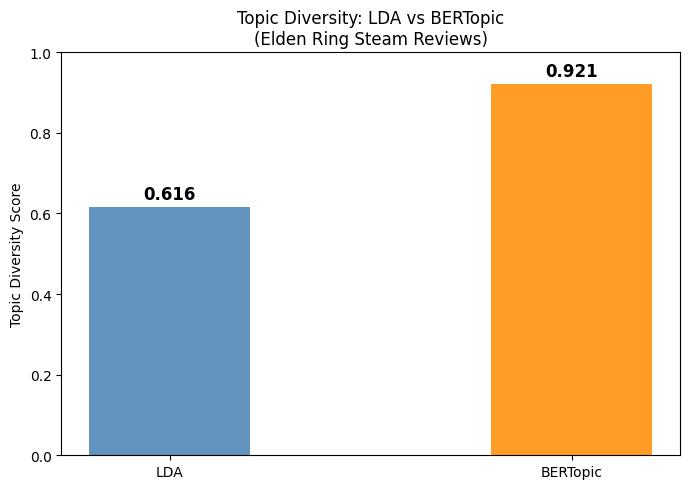

✅ Saved → 3_diversity_comparison.png

⏳ Training final LDA with 6 topics for analysis...

⏳ Training LDA model with 6 topics...

=== LDA Topics ===
Topic 1: ['worth', 'masterpiece', 'attack', 'fromsoft', 'hate', 'enemy', 'miyazaki', 'dlc', 'map', 'fight']
Topic 2: ['amazing', 'die', 'beat', 'hit', 'kill', 'enjoy', 'step', 'dlc', 'hate', 'experience']
Topic 3: ['area', 'beat', 'story', 'easy', 'attack', 'run', 'grind', 'level', 'fight', 'weapon']
Topic 4: ['peak', 'pc', 'amazing', 'experience', 'beat', 'top', 'mod', 'dlc', 'bought', 'xbox']
Topic 5: ['greatest', 'build', 'run', 'tarnished', 'favorite', 'fight', 'land', 'lord', 'become', 'maidenless']
Topic 6: ['combat', 'story', 'experience', 'beautiful', 'enemy', 'build', 'amazing', 'fight', 'gameplay', 'lore']


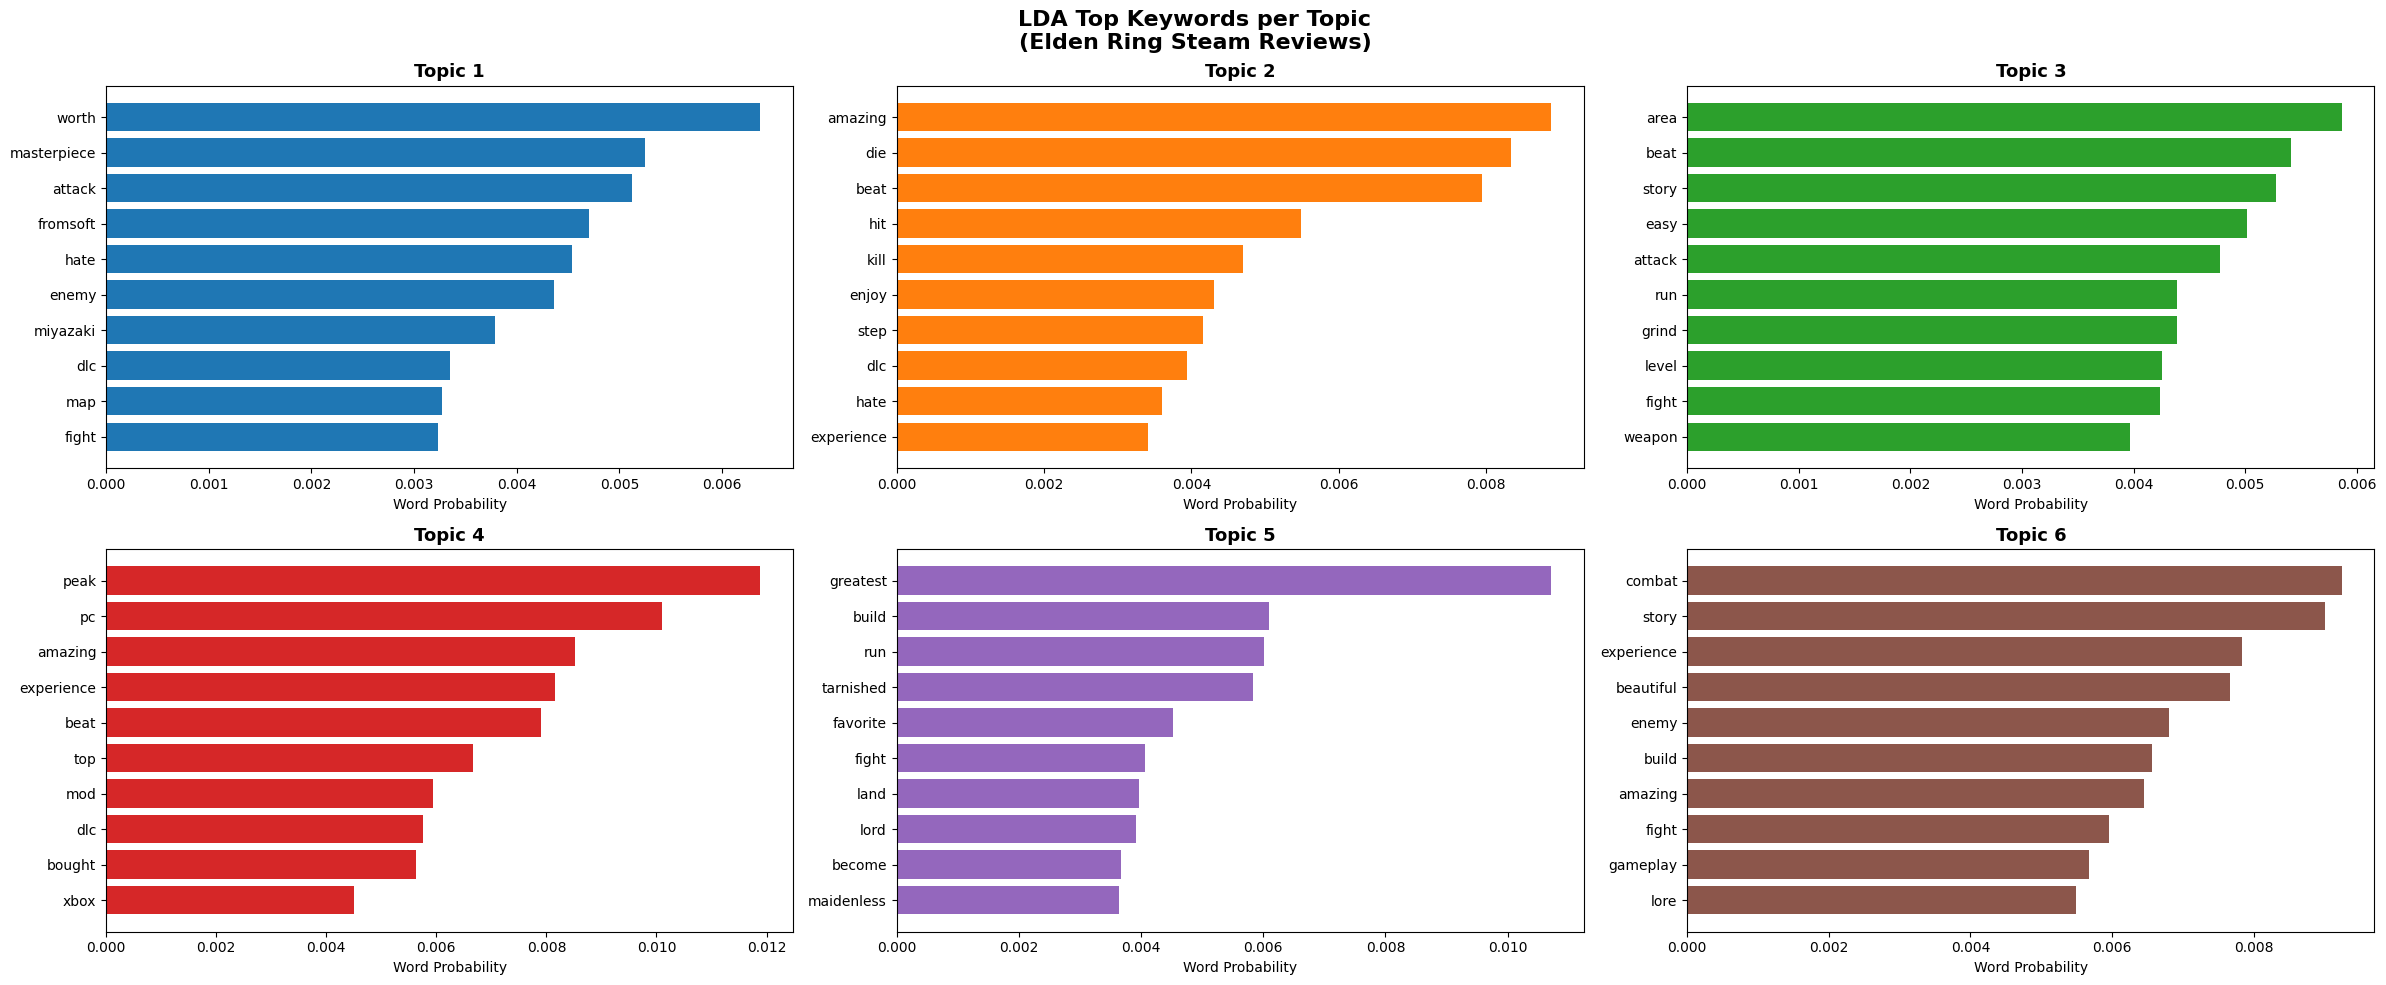

✅ Saved → 4_lda_keywords.png

=== LDA Topic Distribution ===
  Topic 1: 298 reviews (16.4%)
  Topic 2: 208 reviews (11.5%)
  Topic 3: 240 reviews (13.2%)
  Topic 4: 364 reviews (20.0%)
  Topic 5: 296 reviews (16.3%)
  Topic 6: 410 reviews (22.6%)


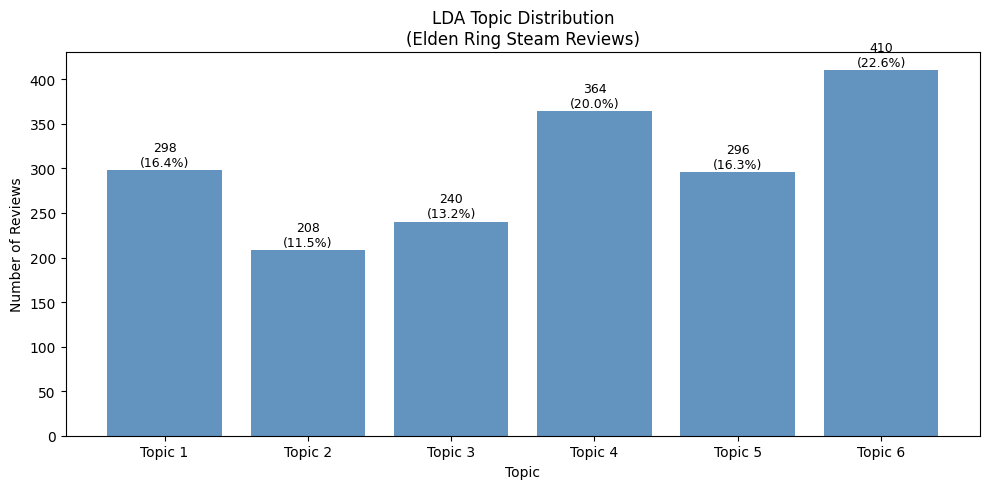

✅ Saved → 5_lda_topic_distribution.png


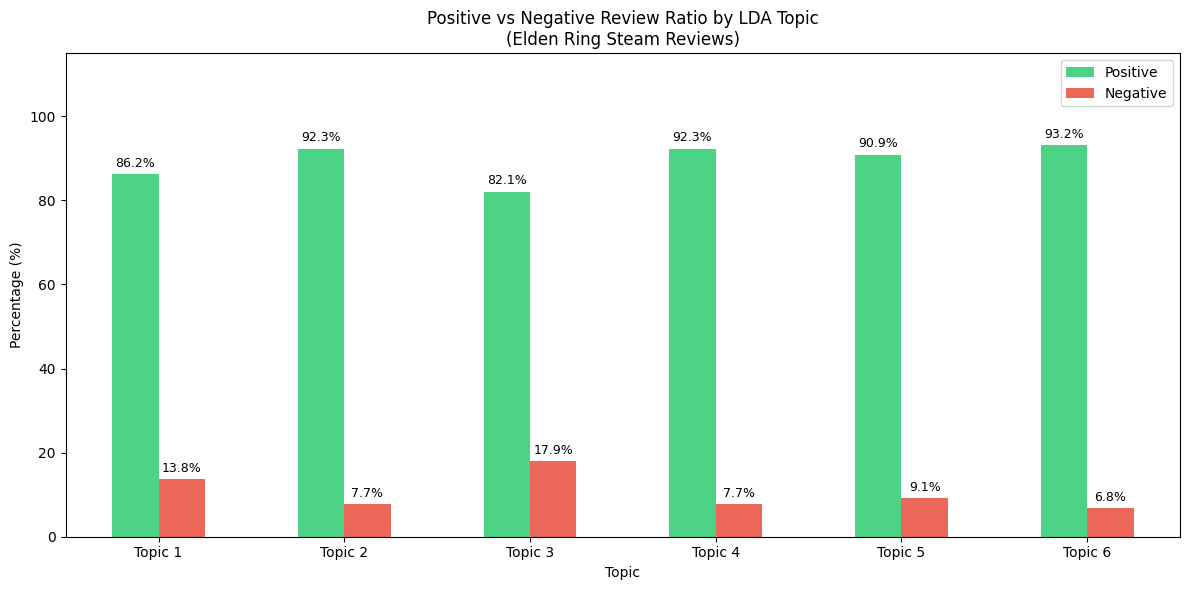

✅ Saved → 6_sentiment_by_topic.png

=== Sentiment Ratio per Topic ===
sentiment  Negative  Positive
Topic 1        13.8      86.2
Topic 2         7.7      92.3
Topic 3        17.9      82.1
Topic 4         7.7      92.3
Topic 5         9.1      90.9
Topic 6         6.8      93.2


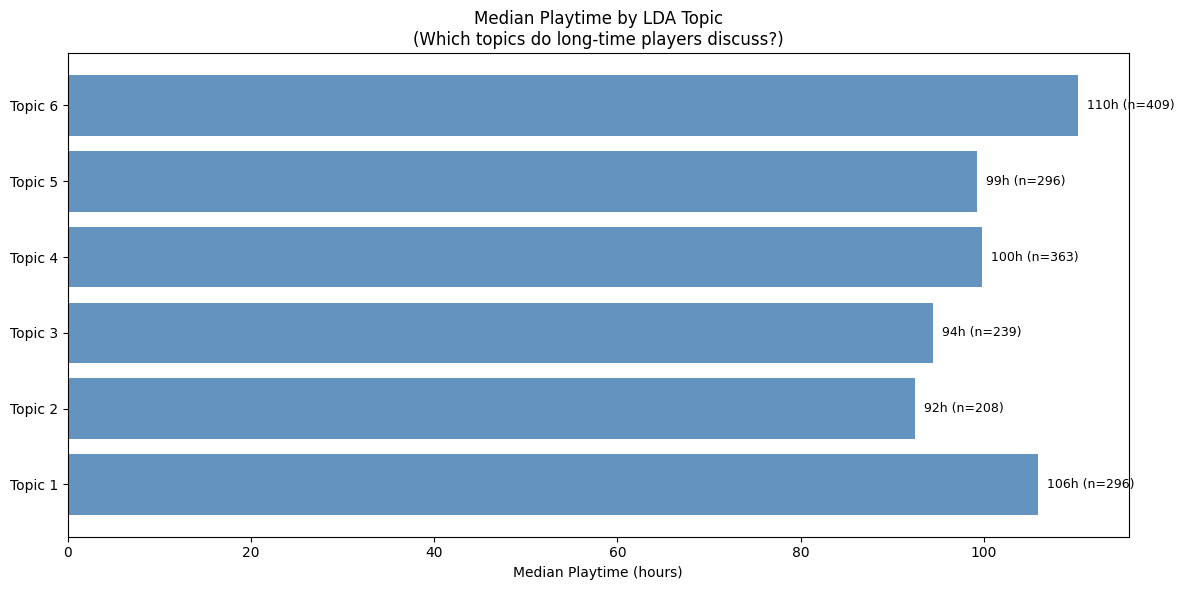

✅ Saved → 7_playtime_by_topic.png

=== Median Playtime per Topic ===
 dominant_topic  median       mean  count
              1  105.90 155.688176    296
              2   92.50 142.265385    208
              3   94.40 151.415063    239
              4   99.80 158.440220    363
              5   99.25 155.721622    296
              6  110.30 167.252323    409

⏳ Generating pyLDAvis visualisation...
✅ Saved → lda_interactive.html

✅ Pipeline complete.


In [27]:
# ============================================================
# MAIN EXECUTION
# ============================================================


# 1. Load data
df_topic = load_reviews('raw_reviews.json', limit=2000)

# 2. Tokenise
df_topic = tokenize_dataframe(df_topic)

# 3. Find optimal number of topics
optimal_n, coherence_scores_list = find_optimal_topics(df_topic, topic_range=range(2, 20))

# 4a. Train LDA with OPTIMAL topics — used for fair comparison only
print(f'\n⏳ Training comparison LDA with optimal {optimal_n} topics...')
lda_comparison, corpus_cmp, dictionary_cmp = train_lda(df_topic, num_topics=optimal_n)

# 5. Train BERTopic (for comparison only)
topic_model, topics, probs = train_bertopic(df_topic)

# 6. Compare Coherence — uses OPTIMAL LDA vs BERTopic (fair) ✅
coherence_lda, coherence_bert = compare_coherence(
    lda_comparison, topic_model, df_topic, dictionary_cmp)

# 7. Compare Diversity — same
lda_div, bert_div = compare_diversity(lda_comparison, topic_model)

# ============================================================
# 4b. Train FINAL LDA with FIXED topics — used for analysis
# NOTE: 6 topics selected because it produces the clearest
#       and most interpretable topic structure for this dataset
FIXED_TOPIC_NUM = 6
print(f'\n⏳ Training final LDA with {FIXED_TOPIC_NUM} topics for analysis...')
lda_model, corpus, dictionary = train_lda(df_topic, num_topics=FIXED_TOPIC_NUM)

# 8. LDA keyword chart
plot_lda_keywords(lda_model)

# 9. LDA topic distribution
df_topic = plot_lda_topic_distribution(lda_model, corpus, df_topic)

# 10. Sentiment breakdown per topic
plot_sentiment_by_topic(df_topic)

# 11. Playtime by topic
plot_playtime_by_topic(df_topic)

# 12. pyLDAvis
vis = plot_pyldavis(lda_model, corpus, dictionary)
vis

print('\n✅ Pipeline complete.')